# 🌍 WIPO Innovation Capabilities Analysis (Simplified)

This notebook provides the core analysis of the WIPO Innovation Capabilities Outlook 2026, focusing on global complexity and Chile's strategic potential.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Load Core Data
outputs = pd.read_parquet('data/outputs.parquet')
caps = pd.read_parquet('data/capabilities.parquet')
pots = pd.read_parquet('data/potentials.parquet')
uc = pd.read_parquet('data/unit_complexities.parquet')
fc = pd.read_parquet('data/field_complexities.parquet')
fields = pd.read_parquet('data/fields.parquet')
units = pd.read_parquet('data/units.parquet')

print("✅ Data loaded successfully.")

✅ Data loaded successfully.


## 2. Global Complexity Leaderboard (2023)

In [2]:
latest = uc[uc['Period'] == 2023].merge(units[units['Period'] == 2023], on=['Period', 'Unit'])
top10 = latest.nlargest(10, 'Ecosystem Complexity Index')[['Unit Name', 'Ecosystem Complexity Index', 'GDP PC']]
display(top10)

,Unit Name,Ecosystem Complexity Index,GDP PC
139,Japan,0.990363,45635.728288
152,Liechtenstein,0.940542,NaN
95,Marshall Islands (the),0.794767,6339.027489
172,Republic of Korea (the),0.744188,50496.708993
7,Andorra,0.737218,65466.878395
10,Germany,0.732925,62553.898938
108,Monaco,0.709675,NaN
59,Switzerland,0.692152,83412.725644
94,France,0.645429,54297.551536
189,Austria,0.641706,65029.491753


## 3. Chile Innovation Profile

Chile ECI (2023): -0.040
Chile Diversity Share: 29.7%


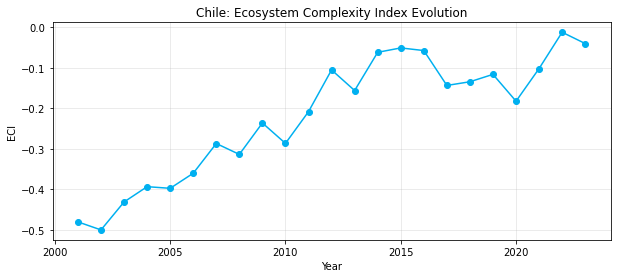

In [3]:
chile_latest = latest[latest['Unit'] == 'CL'].iloc[0]
print(f"Chile ECI (2023): {chile_latest['Ecosystem Complexity Index']:.3f}")
print(f"Chile Diversity Share: {chile_latest['Diversity Share']:.1%}")

# ECI Evolution
chile_ts = uc[uc['Unit'] == 'CL'].sort_values('Period')
plt.figure(figsize=(10, 4))
plt.plot(chile_ts['Period'], chile_ts['Ecosystem Complexity Index'], marker='o', color='#00B0F0')
plt.title('Chile: Ecosystem Complexity Index Evolution')
plt.xlabel('Year')
plt.ylabel('ECI')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Chile's Untapped Strategic Potential
Identifying complex fields where Chile lacks capability but has high proximity/potential.

In [4]:
chile_pots = pots[(pots['Unit'] == 'CL') & (pots['Period'] == 2023)]
chile_caps = caps[(caps['Unit'] == 'CL') & (caps['Period'] == 2023)]

# Merge data to find untapped fields
untapped = chile_pots.merge(chile_caps[['Field ID', 'Innovation Capability (Binary)']], on='Field ID')
untapped = untapped[~untapped['Innovation Capability (Binary)']].merge(fields, on='Field ID')
untapped = untapped.merge(fc[fc['Period'] == 2023][['Field ID', 'Capability Complexity Index']], on='Field ID')

print("Top 15 strategic fields (High Potential & High Complexity) for Chile:")
display(untapped.nlargest(15, 'Potential')[['Field Name', 'Dimension Name', 'Potential', 'Capability Complexity Index']])

Top 15 strategic fields (High Potential & High Complexity) for Chile:


,Field Name,Dimension Name,Potential,Capability Complexity Index
563,Crude Oil,Production,2.449176e+09,-5.630390
558,Coal and Briquettes,Production,2.092980e+09,-3.717491
1117,Passenger Cars,Production,1.658931e+09,1.723820
451,Crustaceans,Production,1.144975e+09,-3.895116
564,Refined Petroleum Products,Production,1.049760e+09,-2.016900
565,Petroleum Gas,Production,8.237135e+08,-3.421187
1122,Vehicle Parts,Production,8.167890e+08,1.401131
621,Retail Pharmaceuticals,Production,8.082279e+08,0.943902
1083,Broadcasting Equipment,Production,7.789001e+08,1.656243
1100,Integrated Circuits,Production,6.387979e+08,2.390900
